# Predictions


In [1]:
import duckdb
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import repl_utils
from variables import Variables as vars

plt.style.use("../../notebook.mplstyle")

START_TIME = datetime.now()
OUTPUT_DIR = f"output/00013-model-predictions-2/{START_TIME:%Y%m%d-%H%M%S}"

SAVE_PLOTS = True

os.makedirs(OUTPUT_DIR, exist_ok=True)

repl_utils.print_environment_info()

print(f"\n--------------------\nOutput directory: {OUTPUT_DIR}\n--------------------\n")

-------------------- Environment Information --------------------
date: 2026-01-25T12:52:01.500245
platform: Windows-11-10.0.26220-SP0
platform_version: 10.0.26220
cpu: Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
cores: 32
physical_cores: 24
ram: 127 GB
ram_available: 83 GB
cuda: True
cuda_device_count: 1
cuda_device_0: NVIDIA GeForce RTX 4070 Ti SUPER
python: 3.13.11 | packaged by conda-forge | (main, Dec  6 2025, 11:10:00) [MSC v.1944 64 bit (AMD64)]
numpy: 2.3.5
pandas: 2.3.3
scipy: 1.16.3
sklearn: 1.8.0
lightgbm: 4.6.0
pytorch: 2.9.1
pymc: 5.27.0
pytensor: 2.36.3
arviz: 0.23.0

--------------------
Output directory: output/00013-model-predictions-2/20260125-125201
--------------------



In [2]:
con = duckdb.connect("./data/us_births.db", read_only=True)

## 3.1. Births predicted from 2016 to 2024


In [3]:
df = con.execute(
    f"""
    SELECT
        b.year,
        sum(b.down_ind) as down_ind,
        sum(b.p_ds_lb_pred_02) as down_pred,
        sum(b.p_ds_lb_pred_02)  / sum(b.down_ind) as ratio,
        sum(b.p_ds_lb_nt * (1 - r.reduction)) as ds_lb_est_reduc
    FROM us_births AS b
    LEFT JOIN reduction_rate_year r
        ON b.year = r.year
    WHERE b.year >= 2016
    GROUP BY b.year
    ORDER BY b.year;
    """
).df()
df

,year,down_ind,down_pred,ratio,ds_lb_est_reduc
0,2016,2168.0,2124.507848,0.979939,5128.850913
1,2017,2044.0,2045.870540,1.000915,5170.826289
2,2018,2108.0,2055.837048,0.975255,5035.392182
3,2019,2030.0,2013.530196,0.991887,5069.181474
4,2020,1954.0,1936.830069,0.991213,4915.527694
5,2021,1903.0,1923.475421,1.010760,5037.277999
6,2022,1861.0,1884.401491,1.012575,5137.556006
7,2023,1855.0,1898.277352,1.023330,5065.777423
8,2024,1886.0,1897.284176,1.005983,5137.562776


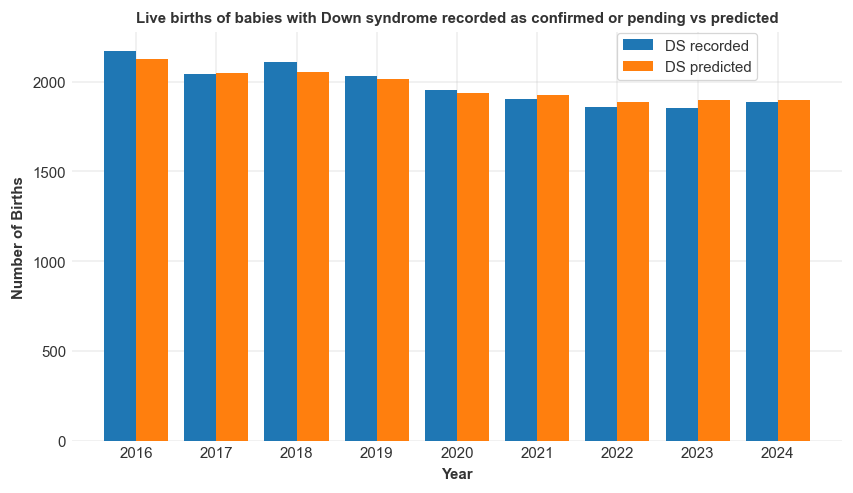

In [4]:
plt.figure(figsize=(7, 4))
# plt.fill_between(range(2003, 2015), 2250, color="#d8f0ff", alpha=0.4)
plt.bar(df["year"] - 0.2, df["down_ind"], width=0.4, label="DS recorded")
plt.bar(df["year"] + 0.2, df["down_pred"], width=0.4, label="DS predicted")
plt.xlim(2015.2, 2024.8)
plt.xticks(range(2016, 2025))
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.title(
    "Live births of babies with Down syndrome recorded as confirmed or pending vs predicted"
)
plt.legend(bbox_to_anchor=(0.9, 0.94), loc="center right")
if SAVE_PLOTS:
    plt.savefig(
        os.path.join(OUTPUT_DIR, "births_recorded_predicted.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        os.path.join(OUTPUT_DIR, "births_recorded_predicted.svg"), bbox_inches="tight"
    )
plt.show()

In [5]:
df = con.execute(
    f"""
    SELECT
        b.year,
        SUM(b.down_ind) AS down_ind,
        (SELECT COUNT(*) FROM us_births WHERE year = b.year AND p_ds_lb_pred_02 >= 0.029) AS down_pred,
        SUM(b.p_ds_lb_nt * (1 - r.reduction)) AS ds_lb_est_reduc
    FROM us_births AS b
    LEFT JOIN reduction_rate_year r
        ON b.year = r.year
    WHERE b.year >= 2016
    GROUP BY b.year
    ORDER BY b.year;
    """
).df()
df

,year,down_ind,down_pred,ds_lb_est_reduc
0,2016,2168.0,5014,5128.850913
1,2017,2044.0,4941,5170.826289
2,2018,2108.0,5177,5035.392182
3,2019,2030.0,5132,5069.181474
4,2020,1954.0,4940,4915.527694
5,2021,1903.0,4576,5037.277999
6,2022,1861.0,4360,5137.556006
7,2023,1855.0,4396,5065.777423
8,2024,1886.0,4422,5137.562776


In [6]:
df = con.execute(
    f"""
    WITH year_quota AS (
        SELECT
            year,
            COUNT(*) AS n_recorded,
            CAST(CEIL(COUNT(*) * 2.5) AS BIGINT) AS n_select
        FROM us_births
        WHERE down_ind = 1
        GROUP BY year
    ),
    ranked AS (
        SELECT
            b.*,
            q.n_recorded,
            q.n_select,
            ROW_NUMBER() OVER (
                PARTITION BY b.year
                ORDER BY b.p_ds_lb_pred_02 DESC
            ) AS rn
        FROM us_births AS b
        JOIN year_quota AS q
        ON q.year = b.year
        WHERE b.p_ds_lb_pred_02 IS NOT NULL
    ),
    selected AS (
        SELECT *
        FROM ranked
        WHERE rn <= n_select
        ORDER BY year, rn
    )
    SELECT
        s.year,
        (SELECT COUNT(*) FROM us_births WHERE year = s.year AND down_ind = 1) AS down_ind_total,
        SUM(down_ind) AS down_ind_sel,
        SUM(down_ind) / (SELECT COUNT(*) FROM us_births WHERE year = s.year AND down_ind = 1) AS down_ind_ratio,
        COUNT(*) AS down_pred
    FROM selected AS s
    LEFT JOIN reduction_rate_year r
        ON s.year = r.year
    WHERE s.year >= 2016
    GROUP BY s.year
    ORDER BY s.year;
    """
).df()
df

,year,down_ind_total,down_ind_sel,down_ind_ratio,down_pred
0,2016,2168,400.0,0.184502,5420
1,2017,2044,355.0,0.173679,5110
2,2018,2108,379.0,0.179791,5270
3,2019,2030,402.0,0.198030,5075
4,2020,1954,375.0,0.191914,4885
5,2021,1903,329.0,0.172885,4758
6,2022,1861,315.0,0.169264,4653
7,2023,1855,301.0,0.162264,4638
8,2024,1886,309.0,0.163839,4715


In [7]:
df = con.execute(
    f"""
    WITH year_month_quota AS (
        SELECT
            year,
            dob_mm,
            COUNT(*) AS n_recorded,
            CAST(CEIL(COUNT(*) * 1.5) AS BIGINT) AS n_select
        FROM us_births
        WHERE down_ind = 1 AND year >= 2016
        GROUP BY year, dob_mm
    ),
    ranked AS (
        SELECT
            b.*,
            q.n_recorded,
            q.n_select,
            ROW_NUMBER() OVER (
                PARTITION BY b.year, b.dob_mm
                ORDER BY b.p_ds_lb_pred_02 DESC
            ) AS rn
        FROM us_births AS b
        JOIN year_month_quota AS q
        ON q.year = b.year AND q.dob_mm = b.dob_mm
        WHERE down_ind = 0
    ),
    missing AS (
        SELECT *
        FROM ranked
        WHERE rn <= n_select
        ORDER BY year, dob_mm, rn
    )
    SELECT
        b.mage_c,
        (SELECT COUNT(*) FROM us_births WHERE mage_c = b.mage_c AND down_ind = 1 AND year >= 2016) as ds_births_recorded,
        COUNT(m.rn) as ds_births_missing,
        (SELECT COUNT(*) FROM us_births WHERE mage_c = b.mage_c AND down_ind = 1 AND year >= 2016) + COUNT(m.rn) as ds_births_total,
        SUM(b.p_ds_lb_nt * (1 - r.reduction)) as ds_lb_est_reduc
    FROM us_births AS b
    FULL OUTER JOIN missing AS m
    ON b.id = m.id
    LEFT JOIN reduction_rate_year r
        ON b.year = r.year
    WHERE b.year >= 2016
    GROUP BY b.mage_c,
    ORDER BY b.mage_c;
    """
).df()
df

,mage_c,ds_births_recorded,ds_births_missing,ds_births_total,ds_lb_est_reduc
0,12,0,2,2,0.233316
1,13,1,2,3,1.133716
2,14,1,8,9,5.478022
3,15,16,5,21,18.249846
4,16,37,26,63,44.931320
5,17,62,55,117,89.641465
6,18,108,130,238,170.652176
7,19,208,232,440,295.999568
8,20,265,302,567,392.275836
9,21,309,375,684,463.329642


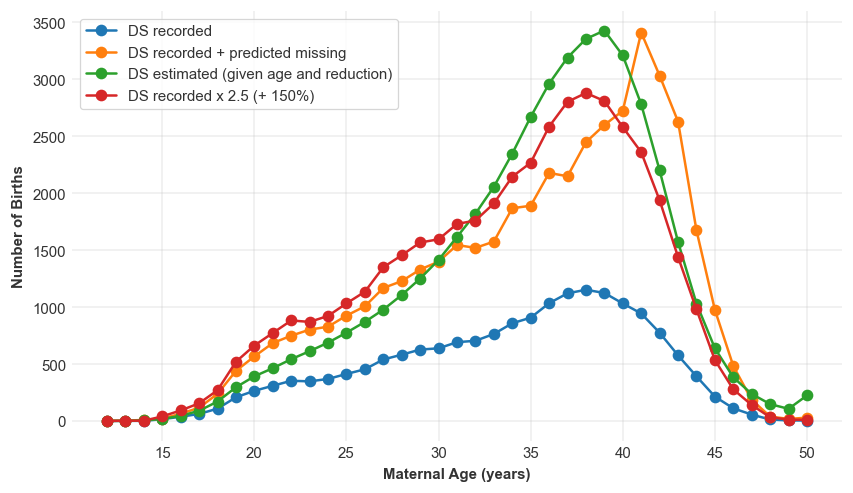

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(df["mage_c"], df["ds_births_recorded"], marker="o", label="DS recorded")
plt.plot(
    df["mage_c"],
    df["ds_births_total"],
    marker="o",
    label="DS recorded + predicted missing",
)
plt.plot(
    df["mage_c"],
    df["ds_lb_est_reduc"],
    marker="o",
    label="DS estimated (given age and reduction)",
)
plt.plot(df["mage_c"], df["ds_births_recorded"] * 2.5, marker="o", label="DS recorded x 2.5 (+ 150%)")

plt.xlabel("Maternal Age (years)")
plt.ylabel("Number of Births")
plt.legend()
plt.show()

In [9]:
df = con.execute(
    f"""
    WITH year_month_quota AS (
        SELECT
            year,
            dob_mm,
            COUNT(*) AS n_recorded,
            CAST(CEIL(COUNT(*) * 1.5) AS BIGINT) AS n_select
        FROM us_births
        WHERE down_ind = 1 AND year >= 2016
        GROUP BY year, dob_mm
    ),
    ranked AS (
        SELECT
            b.*,
            q.n_recorded,
            q.n_select,
            ROW_NUMBER() OVER (
                PARTITION BY b.year, b.dob_mm
                ORDER BY b.p_ds_lb_pred_02 DESC
            ) AS rn
        FROM us_births AS b
        JOIN year_month_quota AS q
        ON q.year = b.year AND q.dob_mm = b.dob_mm
        WHERE down_ind = 0
    ),
    missing AS (
        SELECT *
        FROM ranked
        WHERE rn <= n_select
        ORDER BY year, dob_mm, rn
    )
    SELECT
        b.mracehisp,
        (SELECT COUNT(*) FROM us_births WHERE mracehisp = b.mracehisp AND down_ind = 1 AND year >= 2016) as ds_births_recorded,
        COUNT(m.rn) as ds_births_missing,
        COUNT(m.rn) / (SELECT COUNT(*) FROM us_births WHERE mracehisp = b.mracehisp AND down_ind = 1 AND year >= 2016) as ds_births_missing_ratio,
        (SELECT COUNT(*) FROM us_births WHERE mracehisp = b.mracehisp AND down_ind = 1 AND year >= 2016) + COUNT(m.rn) as ds_births_total,
        SUM(b.p_ds_lb_nt * (1 - r.reduction)) as ds_lb_est_reduc
    FROM us_births AS b
    FULL OUTER JOIN missing AS m
    ON b.id = m.id
    LEFT JOIN reduction_rate_year r
        ON b.year = r.year
    WHERE b.year >= 2016
    GROUP BY b.mracehisp
    ORDER BY b.mracehisp;
    """
).df()
df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,mracehisp,ds_births_recorded,ds_births_missing,ds_births_missing_ratio,ds_births_total,ds_lb_est_reduc
0,1,9419,13961,1.482217,23380,23134.543163
1,2,1998,2460,1.231231,4458,6084.122748
2,3,184,257,1.396739,441,257.861261
3,4,628,760,1.210191,1388,4006.877612
4,5,41,72,1.756098,113,107.329565
5,6,383,513,1.339426,896,896.539522
6,7,4969,8482,1.706983,13451,10569.415035
7,8,187,237,1.267380,424,641.263850


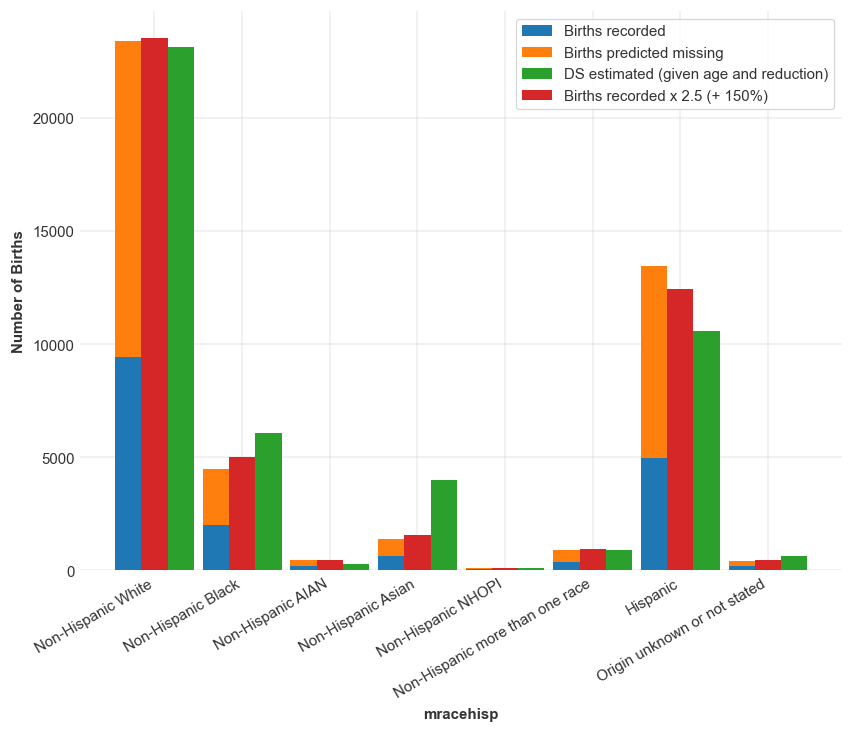

In [10]:
x_labels = {
    1: "Non-Hispanic White",
    2: "Non-Hispanic Black",
    3: "Non-Hispanic AIAN",
    4: "Non-Hispanic Asian",
    5: "Non-Hispanic NHOPI",
    6: "Non-Hispanic more than one race",
    7: "Hispanic",
    8: "Origin unknown or not stated",
}

plt.figure(figsize=(7, 6))
plt.bar(
    df["mracehisp"] - 0.3, df["ds_births_recorded"], width=0.3, label="Births recorded"
)
plt.bar(
    df["mracehisp"] - 0.3,
    df["ds_births_missing"],
    width=0.3,
    bottom=df["ds_births_recorded"],
    label="Births predicted missing",
)
plt.bar(
    df["mracehisp"] + 0.3, df["ds_lb_est_reduc"], width=0.3, label="DS estimated (given age and reduction)"
)
plt.bar(
    df["mracehisp"], df["ds_births_recorded"] * 2.5, width=0.3, label="Births recorded x 2.5 (+ 150%)"
)

plt.xlabel("mracehisp")
plt.ylabel("Number of Births")
plt.xticks(
    df["mracehisp"],
    [x_labels.get(x, "Unknown") for x in df["mracehisp"]],
    rotation=30,
    ha="right",
)
plt.legend()
plt.show()

In [11]:
df = con.execute(
    f"""
    WITH year_month_quota AS (
        SELECT
            year,
            dob_mm,
            COUNT(*) AS n_recorded,
            CAST(CEIL(COUNT(*) * 1.5) AS BIGINT) AS n_select
        FROM us_births
        WHERE down_ind = 1 AND year >= 2016
        GROUP BY year, dob_mm
    ),
    ranked AS (
        SELECT
            b.*,
            q.n_recorded,
            q.n_select,
            ROW_NUMBER() OVER (
                PARTITION BY b.year, b.dob_mm
                ORDER BY b.p_ds_lb_pred_02 DESC
            ) AS rn
        FROM us_births AS b
        JOIN year_month_quota AS q
        ON q.year = b.year AND q.dob_mm = b.dob_mm
        WHERE down_ind = 0
    ),
    missing AS (
        SELECT *
        FROM ranked
        WHERE rn <= n_select
        ORDER BY year, dob_mm, rn
    )
    SELECT
        b.meduc,
        (SELECT COUNT(*) FROM us_births WHERE meduc = b.meduc AND down_ind = 1 AND year >= 2016) as ds_births_recorded,
        COUNT(m.rn) as ds_births_missing,
        COUNT(m.rn) / (SELECT COUNT(*) FROM us_births WHERE meduc = b.meduc AND down_ind = 1 AND year >= 2016) as ds_births_missing_ratio,
        (SELECT COUNT(*) FROM us_births WHERE meduc = b.meduc AND down_ind = 1 AND year >= 2016) + COUNT(m.rn) as ds_births_total,
        SUM(b.p_ds_lb_nt * (1 - r.reduction)) as ds_lb_est_reduc
    FROM us_births AS b
    FULL OUTER JOIN missing AS m
    ON b.id = m.id
    LEFT JOIN reduction_rate_year r
        ON b.year = r.year
    WHERE b.year >= 2016
    GROUP BY b.meduc
    ORDER BY b.meduc;
    """
).df()
df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,meduc,ds_births_recorded,ds_births_missing,ds_births_missing_ratio,ds_births_total,ds_lb_est_reduc
0,1,1285,3472,2.701946,4757,1924.233598
1,2,1585,2545,1.605678,4130,2946.124345
2,3,4066,6101,1.500492,10167,8427.232655
3,4,3183,4509,1.416588,7692,7113.182768
4,5,1616,2296,1.420792,3912,3762.265373
5,6,3726,5201,1.395867,8927,11454.703107
6,7,1625,1838,1.131077,3463,6712.211545
7,8,413,432,1.046005,845,2384.750298
8,9,310,348,1.122581,658,973.249065


In [12]:
df

,meduc,ds_births_recorded,ds_births_missing,ds_births_missing_ratio,ds_births_total,ds_lb_est_reduc
0,1,1285,3472,2.701946,4757,1924.233598
1,2,1585,2545,1.605678,4130,2946.124345
2,3,4066,6101,1.500492,10167,8427.232655
3,4,3183,4509,1.416588,7692,7113.182768
4,5,1616,2296,1.420792,3912,3762.265373
5,6,3726,5201,1.395867,8927,11454.703107
6,7,1625,1838,1.131077,3463,6712.211545
7,8,413,432,1.046005,845,2384.750298
8,9,310,348,1.122581,658,973.249065


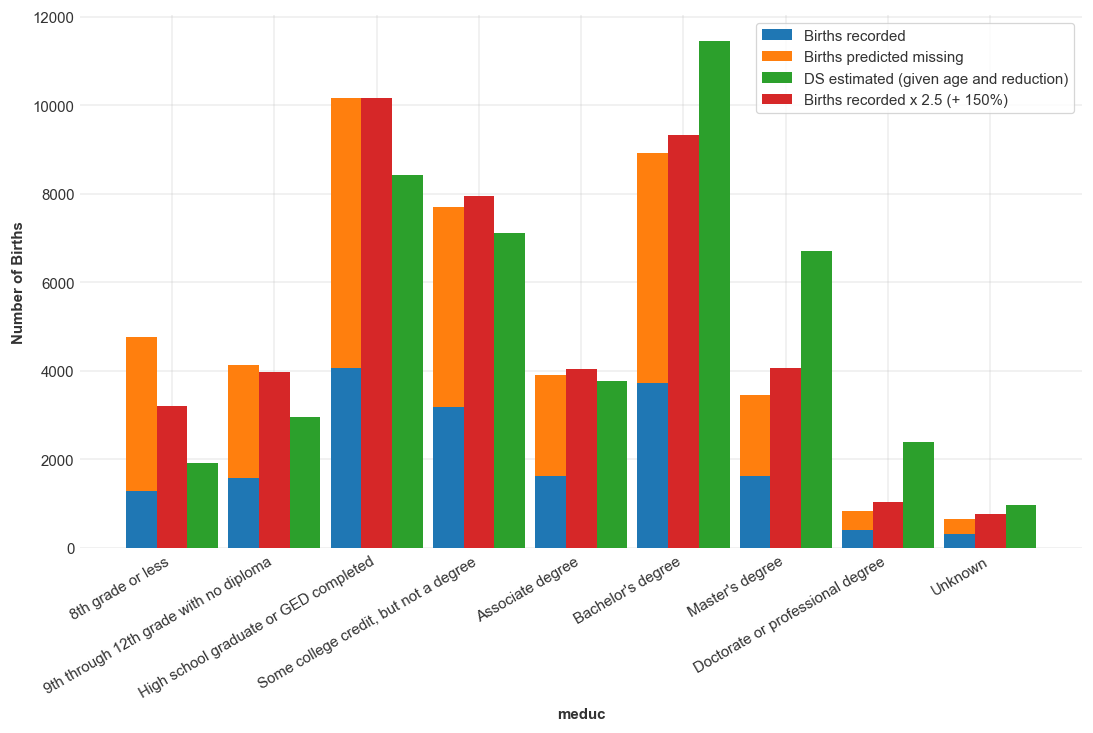

In [13]:
x_labels = {
    1: "8th grade or less",
    2: "9th through 12th grade with no diploma",
    3: "High school graduate or GED completed",
    4: "Some college credit, but not a degree",
    5: "Associate degree",
    6: "Bachelor's degree",
    7: "Master's degree",
    8: "Doctorate or professional degree",
    9: "Unknown",
}

plt.figure(figsize=(9, 6))
plt.bar(
    df["meduc"] - 0.3, df["ds_births_recorded"], width=0.3, label="Births recorded"
)
plt.bar(
    df["meduc"] - 0.3,
    df["ds_births_missing"],
    width=0.3,
    bottom=df["ds_births_recorded"],
    label="Births predicted missing",
)
plt.bar(
    df["meduc"] + 0.3, df["ds_lb_est_reduc"], width=0.3, label="DS estimated (given age and reduction)"
)
plt.bar(
    df["meduc"], df["ds_births_recorded"] * 2.5, width=0.3, label="Births recorded x 2.5 (+ 150%)"
)

plt.xlabel("meduc")
plt.ylabel("Number of Births")
plt.xticks(
    df["meduc"],
    [x_labels.get(x, "Unknown") for x in df["meduc"]],
    rotation=30,
    ha="right",
)
plt.legend()
plt.show()

C:\Users\FrankBuckley\AppData\Local\Temp\ipykernel_9492\897196897.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


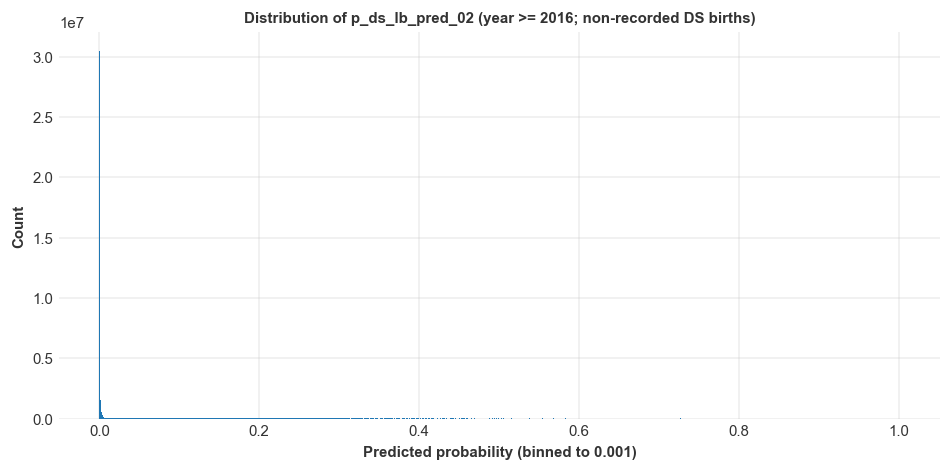

C:\Users\FrankBuckley\AppData\Local\Temp\ipykernel_9492\897196897.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


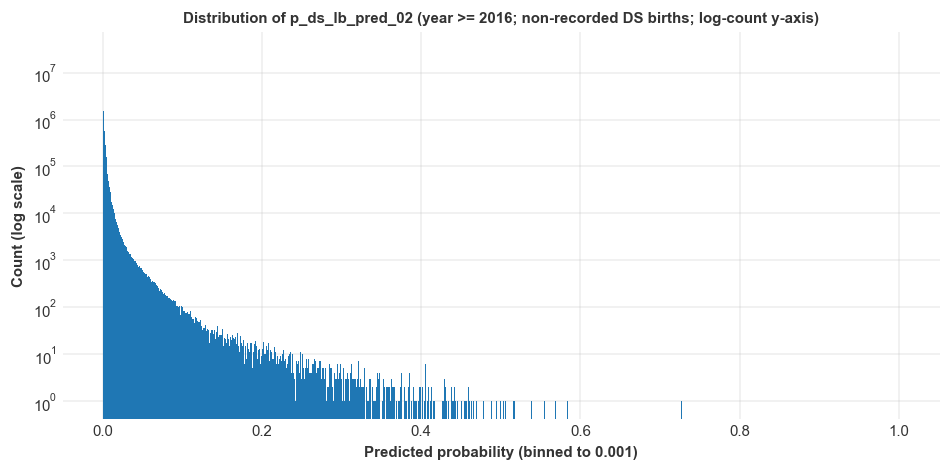

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1000 bins: [0.000, 0.001), [0.001, 0.002), ..., [0.999, 1.000]
bins_df = con.execute(
    """
    SELECT
        CAST(FLOOR(p_ds_lb_pred_02 * 1000) AS INTEGER) AS bin_idx,
        COUNT(*) AS n
    FROM us_births
    WHERE year >= 2016
      AND down_ind = 0
    GROUP BY 1
    ORDER BY 1
"""
).df()

# Ensure all bins 0..1000 exist (bin_idx=1000 would only happen if p==1.0 exactly)
all_bins = pd.DataFrame({"bin_idx": np.arange(0, 1001, dtype=int)})
bins_df = all_bins.merge(bins_df, on="bin_idx", how="left").fillna({"n": 0})
bins_df["n"] = bins_df["n"].astype(np.int64)

# Bin left-edge as the plotted x (e.g., 0.000, 0.001, 0.002, ...)
bins_df["p_left"] = bins_df["bin_idx"] / 1000.0

plt.figure(figsize=(8, 4))
plt.bar(bins_df["p_left"], bins_df["n"], width=0.001, align="edge")
plt.xlabel("Predicted probability (binned to 0.001)")
plt.ylabel("Count")
plt.title("Distribution of p_ds_lb_pred_02 (year >= 2016; non-recorded DS births)")
plt.tight_layout()
plt.show()

# Often useful for highly skewed distributions:
plt.figure(figsize=(8, 4))
plt.bar(bins_df["p_left"], bins_df["n"], width=0.001, align="edge")
plt.yscale("log")
plt.xlabel("Predicted probability (binned to 0.001)")
plt.ylabel("Count (log scale)")
plt.title("Distribution of p_ds_lb_pred_02 (year >= 2016; non-recorded DS births; log-count y-axis)")
plt.tight_layout()
plt.show()

In [ ]:
con.close()